# MMA860  - Assignment 01, Finch Team, March 27, 2026
# Memebrs:
* Bachir Chehab (4sntk@queensu.ca),
* Nicole Yang (25sq17@queensu.ca),
* Lionel Wang (25dd22@queensu.ca),
* Abdallah Lakis (25dp35@queensu.ca),
* Muna Zhou (25sg37@queensu.ca),
* Alan Jamra (25rgc5@queensu.ca).

---

# IMPORTS AND FILE INPUT

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.formula.api import ols

xl = pd.ExcelFile("/Users/bachir/Desktop/860_Assignment1_Data_vf.xlsx")

weather = pd.read_excel(xl, sheet_name="Island Airport Weather", header=16)
turbine_specs = pd.read_excel(xl, sheet_name="Turbine Specifications")
turbine_locs  = pd.read_excel(xl, sheet_name="Windfarm Turbine Locations")

In [4]:
###----- gave each sheet we need a different name-----

df_weather = pd.read_excel(xl, sheet_name="Island Airport Weather", header=16) 
df_specs = pd.read_excel(xl, sheet_name="Turbine Specifications")
df_locs = pd.read_excel(xl, sheet_name="Windfarm Turbine Locations")

------

#  Question 1 - Exploration (Abdallah)


## Weather Sheet

In [5]:

df_weather.info()
df_weather.describe()

<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Month                744 non-null    int64  
 1   Day                  744 non-null    int64  
 2   Time                 744 non-null    object 
 3   Temp (°C)            744 non-null    float64
 4   Temp Flag            0 non-null      float64
 5   Dew Point Temp (°C)  744 non-null    float64
 6   Dew Point Temp Flag  0 non-null      float64
 7   Rel Hum (%)          744 non-null    int64  
 8   Rel Hum Flag         0 non-null      float64
 9   Wind Dir (10s deg)   723 non-null    float64
 10  Wind Dir Flag        13 non-null     str    
 11  Wind Spd (km/h)      744 non-null    int64  
 12  Wind Spd Flag        0 non-null      float64
 13  Visibility (km)      744 non-null    float64
 14  Visibility Flag      0 non-null      float64
 15  Stn Press (kPa)      744 non-null    float64
 16  S

,Month,Day,Temp (°C),Temp Flag,Dew Point Temp (°C),Dew Point Temp Flag,Rel Hum (%),Rel Hum Flag,Wind Dir (10s deg),Wind Spd (km/h),Wind Spd Flag,Visibility (km),Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag
count,744.0,744.000000,744.000000,0.0,744.000000,0.0,744.000000,0.0,723.000000,744.000000,0.0,744.000000,0.0,744.000000,0.0,0.0,0.0,547.000000,0.0
mean,1.0,16.000000,-5.134409,NaN,-9.684005,NaN,71.392473,NaN,21.969571,22.740591,NaN,13.964651,NaN,100.883831,NaN,NaN,NaN,-15.343693,NaN
std,0.0,8.950289,6.438515,NaN,7.659632,NaN,12.821447,NaN,9.890350,11.756441,NaN,4.449226,NaN,0.963071,NaN,NaN,NaN,7.599328,NaN
min,1.0,1.000000,-21.000000,NaN,-28.400000,NaN,36.000000,NaN,1.000000,0.000000,NaN,0.200000,NaN,98.470000,NaN,NaN,NaN,-36.000000,NaN
25%,1.0,8.000000,-9.325000,NaN,-15.700000,NaN,62.000000,NaN,11.000000,13.000000,NaN,16.100000,NaN,100.097500,NaN,NaN,NaN,-20.000000,NaN
50%,1.0,16.000000,-4.700000,NaN,-9.850000,NaN,71.000000,NaN,25.000000,22.000000,NaN,16.100000,NaN,100.915000,NaN,NaN,NaN,-13.000000,NaN
75%,1.0,24.000000,0.100000,NaN,-3.600000,NaN,80.000000,NaN,30.000000,30.000000,NaN,16.100000,NaN,101.660000,NaN,NaN,NaN,-9.000000,NaN
max,1.0,31.000000,7.400000,NaN,5.600000,NaN,99.000000,NaN,36.000000,61.000000,NaN,16.100000,NaN,102.870000,NaN,NaN,NaN,-3.000000,NaN


In [6]:
df_weather.head()

,Month,Day,Time,Temp (°C),Temp Flag,Dew Point Temp (°C),Dew Point Temp Flag,Rel Hum (%),Rel Hum Flag,Wind Dir (10s deg),...,Wind Spd Flag,Visibility (km),Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather
0,1,1,00:00:00,4.3,NaN,4.0,NaN,98,NaN,8.0,...,NaN,4.8,NaN,98.49,NaN,NaN,NaN,NaN,NaN,"Rain,Fog"
1,1,1,01:00:00,5.1,NaN,5.0,NaN,99,NaN,NaN,...,NaN,16.1,NaN,98.47,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,02:00:00,5.9,NaN,5.6,NaN,98,NaN,31.0,...,NaN,4.0,NaN,98.57,NaN,NaN,NaN,NaN,NaN,"Rain,Fog"
3,1,1,03:00:00,3.3,NaN,2.6,NaN,95,NaN,30.0,...,NaN,16.1,NaN,98.98,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,04:00:00,2.8,NaN,1.2,NaN,89,NaN,30.0,...,NaN,16.1,NaN,99.29,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#---- checking for missing values----#

df_weather.isnull().sum()


Month                    0
Day                      0
Time                     0
Temp (°C)                0
Temp Flag              744
Dew Point Temp (°C)      0
Dew Point Temp Flag    744
Rel Hum (%)              0
Rel Hum Flag           744
Wind Dir (10s deg)      21
Wind Dir Flag          731
Wind Spd (km/h)          0
Wind Spd Flag          744
Visibility (km)          0
Visibility Flag        744
Stn Press (kPa)          0
Stn Press Flag         744
Hmdx                   744
Hmdx Flag              744
Wind Chill             197
Wind Chill Flag        744
Weather                522
dtype: int64

## Island Airport Data Exploration Summary

The weather dataset contains 744 rows — exactly 24 hours × 31 days of January, meaning no hourly readings are missing.

The three columns we need for our calculations are complete with no missing values:
- **Temp (°C)** — used to calculate air density
- **Stn Press (kPa)** — used to calculate air density
- **Wind Spd (km/h)** — used to calculate power output

The remaining columns (flag columns, wind direction, humidity, etc.) are not needed for this analysis and can be ignored.

The data is clean and ready for calculation.

## Turbine Specs sheet

In [8]:
df_specs.head()

,Field,Comments,Values,Units
0,Wind facility name/ID,The name of the wind facility,Toronto Wind One,NaN
1,Number of turbines,Number of turbines at this facility,49,NaN
2,Cut-in windspeed (m/s),The minimum wind speed needed for the turbine ...,4,m/s
3,Cut-out windspeed (m/s),The maximum wind speed at which the turbine wi...,32,m/s
4,Maximum power coefficient,"Generally accepted to be from 0.25 to 0.45, us...",0.35,NaN


In [9]:
df_specs.tail()

,Field,Comments,Values,Units
2,Cut-in windspeed (m/s),The minimum wind speed needed for the turbine ...,4,m/s
3,Cut-out windspeed (m/s),The maximum wind speed at which the turbine wi...,32,m/s
4,Maximum power coefficient,"Generally accepted to be from 0.25 to 0.45, us...",0.35,NaN
5,Turbine swept area,"The area swept by the turbine blades, if this ...",13273.23,m^2
6,Turbine nominal power,The maximum power output of the turbine,4,MW


## Turbine Specifications Summary 
The specs sheet contains 7 rows with all the constants we need for our calculations: cut-in speed (4 m/s), cut-out speed (32 m/s), power coefficient (0.35), swept area (13,273.23 m²), and nominal power (4 MW). We used head() and tail() to view all rows since the dataset is small — describe() and isnull() would be overkill here since you can literally see all the values with your own eyes.



## Turbine Locations sheet


In [10]:
df_locs.head()

,Turbine #,Latitude,Longitude
0,1,43.558445,-79.394284
1,2,43.558445,-79.387498
2,3,43.558445,-79.380712
3,4,43.558445,-79.373926
4,5,43.558445,-79.367140


In [11]:
df_locs.describe()

,Turbine #,Latitude,Longitude
count,49.00000,49.000000,49.000000
mean,25.00000,43.578803,-79.373926
std,14.28869,0.013713,0.013713
min,1.00000,43.558445,-79.394284
25%,13.00000,43.565231,-79.387498
50%,25.00000,43.578803,-79.373926
75%,37.00000,43.592375,-79.360354
max,49.00000,43.599161,-79.353568


## Turbine Locations Summary
49 turbines with latitude and longitude coordinates, all located in Lake Ontario south of Toronto. No missing values.

# Calculations 

## Constants
We manually extracted the turbine constants from the df_specs sheet we explored earlier.

In [12]:
cut_in = 4          # m/s
cut_out = 32        # m/s
Cp = 0.35
swept_area = 13273.23  # m²
nominal_MW = 4      # MW
n_turbines = 49

## 1a - Air Density

Air density is not included in the weather data, so we need to calculate it ourselves. 
We use the temperature and station pressure readings from df_weather and apply the formula 
provided in the assignment. The result is saved as a new column in df_weather called 
'Air Density (kg/m3)' so we can use it later in the power calculation.

In [13]:
df_weather['Air Density (kg/m3)'] = (df_weather['Stn Press (kPa)'] * 1000) / (287.05 * (df_weather['Temp (°C)'] + 273.15))

df_weather[['Month', 'Day', 'Time', 'Stn Press (kPa)', 'Temp (°C)', 'Air Density (kg/m3)']].head()

,Month,Day,Time,Stn Press (kPa),Temp (°C),Air Density (kg/m3)
0,1,1,00:00:00,98.49,4.3,1.236659
1,1,1,01:00:00,98.47,5.1,1.232853
2,1,1,02:00:00,98.57,5.9,1.230567
3,1,1,03:00:00,98.98,3.3,1.247307
4,1,1,04:00:00,99.29,2.8,1.253480


## 1b - Wind Speed Conversion

The power formula requires wind speed in meters per second (m/s), but our weather data 
provides it in km/h. We convert it by multiplying by 0.277778 and save it as a new column 
in df_weather called 'Wind Spd (m/s)' so we can use it in the power calculation.

In [14]:
df_weather['Wind Spd (m/s)'] = df_weather['Wind Spd (km/h)'] * 0.277778

df_weather[['Month', 'Day', 'Time', 'Wind Spd (km/h)', 'Wind Spd (m/s)']].head()

,Month,Day,Time,Wind Spd (km/h),Wind Spd (m/s)
0,1,1,00:00:00,11,3.055558
1,1,1,01:00:00,4,1.111112
2,1,1,02:00:00,28,7.777784
3,1,1,03:00:00,34,9.444452
4,1,1,04:00:00,28,7.777784


## 1c - Power per Turbine

### We calculate the power output for each turbine for each hour of January using the formula  provided in the assignment. Two conditions apply: if the wind speed is below the cut-in  speed (4 m/s) or above the cut-out speed (32 m/s), the turbine is not operating and power is 0. We also cap the output at the turbine's nominal power of 4 MW (4,000,000 watts). 
### The result is saved as a new column in df_weather called 'Power per Turbine (W)'.

In [15]:
# The nominal power in df_specs is in MW, but our formula works in watts
# so we convert it: 4 MW = 4,000,000 watts
nominal_W = nominal_MW * 1_000_000

# We define a function that takes one row (one hour of weather data) and returns the power output
# We use a function because we have conditions to check before applying the formula
def calc_power(row):
    
    # grab the wind speed for this specific hour
    ws = row['Wind Spd (m/s)']
    
    # if wind speed is below cut-in (4 m/s) or above cut-out (32 m/s)
    # the turbine brakes are applied and it produces no power
    if ws < cut_in or ws > cut_out:
        return 0.0
    
    # otherwise apply the power formula from the assignment
    power = row['Air Density (kg/m3)'] * swept_area * 0.5 * (ws ** 3) * Cp
    
    # a turbine can never produce more than its nominal power (4 MW)
    # min() ensures we cap the output if the formula exceeds that limit
    return min(power, nominal_W)

# apply our function to every single row in df_weather
# axis=1 means we are applying it row by row (not column by column)
df_weather['Power per Turbine (W)'] = df_weather.apply(calc_power, axis=1)

# print the first 5 records as required by the assignment
df_weather[['Month', 'Day', 'Time', 'Wind Spd (m/s)', 'Power per Turbine (W)']].head()

,Month,Day,Time,Wind Spd (m/s),Power per Turbine (W)
0,1,1,00:00:00,3.055558,0.000000e+00
1,1,1,01:00:00,1.111112,0.000000e+00
2,1,1,02:00:00,7.777784,1.344892e+06
3,1,1,03:00:00,9.444452,2.440722e+06
4,1,1,04:00:00,7.777784,1.369935e+06


## 1c-i - Total Windfarm Output

### Now that we have the power output per turbine per hour, we can calculate the total power produced by the entire windfarm in January. We multiply the sum of all hourly power readings by 49 (the number of turbines) and convert from watts to megawatts by dividing by 1,000,000.

In [16]:
# sum up all the hourly power readings for one turbine across all of January
# multiply by 49 to get the total for all turbines
# divide by 1,000,000 to convert from watts to megawatts
total_MW = (df_weather['Power per Turbine (W)'].sum() * n_turbines) / 1_000_000

# print the result
print(f'Total power produced by the windfarm in January: {total_MW:,.2f} MW')

Total power produced by the windfarm in January: 43,077.82 MW


## 1c-ii - Daily Power Production Visualization

### Before we plot, we need to aggregate the hourly power readings into daily totals we group by day, sum up all the hourly readings, multiply by 49 turbines, and convert to megawatts. This gives us one total power value per day for the entire windfarm.

In [17]:
# group df_weather by day and sum up all hourly power readings
# multiply by n_turbines (49) to get the total for all turbines
# divide by 1,000,000 to convert from watts to megawatts
daily_power = df_weather.groupby('Day')['Power per Turbine (W)'].sum() * n_turbines / 1_000_000

# reset_index() turns the result back into a regular dataframe
# without this, Day would be the index instead of a column
daily_power = daily_power.reset_index()

# rename the columns to something clear and readable
daily_power.columns = ['Day', 'Daily Power (MW)']

# preview the first 5 rows to confirm it looks right
daily_power.head()

,Day,Daily Power (MW)
0,1,710.760197
1,2,109.872914
2,3,1515.138015
3,4,589.773248
4,5,453.394928


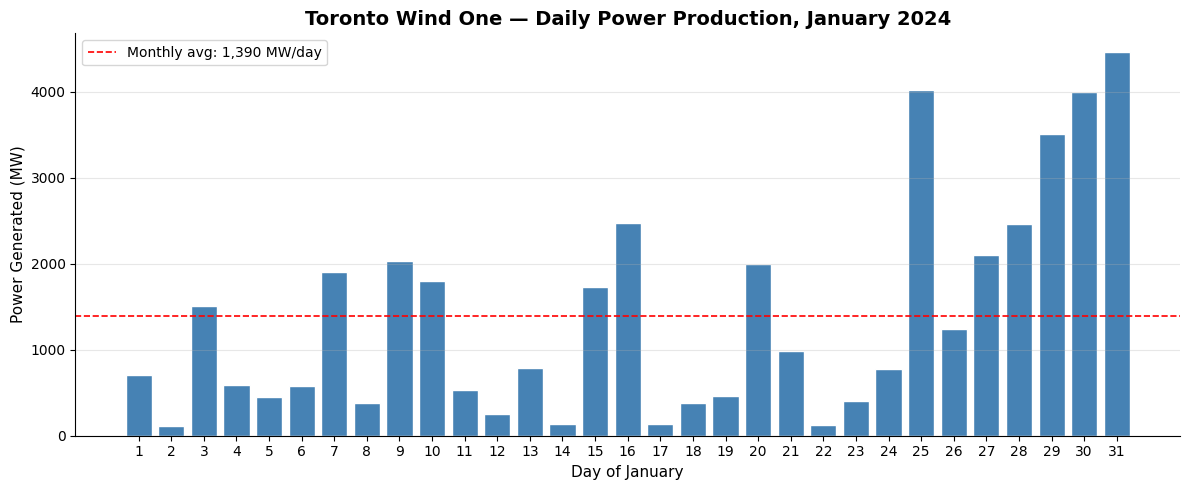

In [18]:
# create the figure and axes, figsize sets the width and height in inches
fig, ax = plt.subplots(figsize=(12, 5))

# draw the bar chart, x is the day, y is the daily power
ax.bar(daily_power['Day'], daily_power['Daily Power (MW)'], color='steelblue', edgecolor='white')

# add a title to the chart
ax.set_title('Toronto Wind One — Daily Power Production, January 2024', fontsize=14, fontweight='bold')

# label the x and y axes
ax.set_xlabel('Day of January', fontsize=11)
ax.set_ylabel('Power Generated (MW)', fontsize=11)

# make sure every day (1-31) shows up on the x axis
ax.set_xticks(daily_power['Day'])

# add a horizontal dashed red line showing the monthly average
ax.axhline(daily_power['Daily Power (MW)'].mean(), color='red', linestyle='--', linewidth=1.2, label=f"Monthly avg: {daily_power['Daily Power (MW)'].mean():,.0f} MW/day")

# add a legend to explain the red dashed line
ax.legend(fontsize=10)

# remove the top and right borders to make the chart cleaner
ax.spines[['top', 'right']].set_visible(False)

# add light horizontal gridlines to make values easier to read
ax.grid(axis='y', alpha=0.3)

# automatically adjust spacing so nothing gets cut off
plt.tight_layout()

# display the chart
plt.show()

## Chart Observations

### The bar chart shows daily power production for the entire windfarm across January 2024. Power output varies significantly from day to day, driven entirely by wind conditions. The second half of January was notably windier, with the last few days (29-31) being the most productive. The monthly average was 1,390 MW/day, with many days falling below that average, particularly in the first half of the month.

---

# Q2 (Muna & Nicole)

Present the data and a story to the executive team at Ontario Power Generation.
    a. Create either: 3 marks</br>
        i.	A consulting-style PowerPoint presentation (maximum 3 slides) OR </br>
        ii.	A business memo (maximum 1 page, not including visuals). </br>
    b.	Produce at least 2 visualizations appropriate for a business leader and include them in your presentation or memo. Do not re-use the visualization from question 1. 4 marks</br>
        c.	Make sure you include recommendations as part of the story. 3 marks</br>

The output should not contain any overtly technical material. Given you do not have any organizational or strategy information, feel free to make any assumptions you need and state them. If you are using PowerPoint submit it as a separate file. Any Tableau visualizations should be pasted into PowerPoint or Word and submitted that way.</br>

Hint: we learned two storytelling narrative techniques – we’ll be looking for evidence of those!</br>

Extra hint: any reasonable assumptions are fair. Perhaps you have been contracted to determine if the turbines are worth installing, or that the turbines have been purchased but now need a location. I am flexible here. 

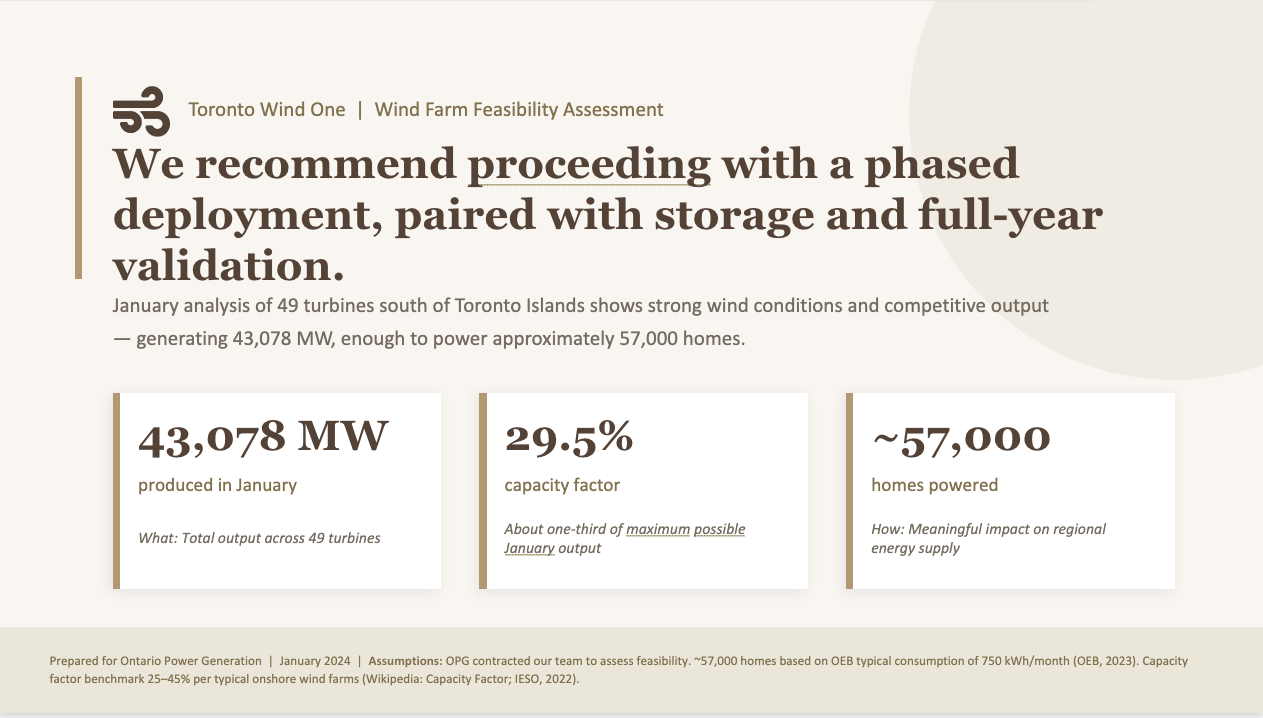

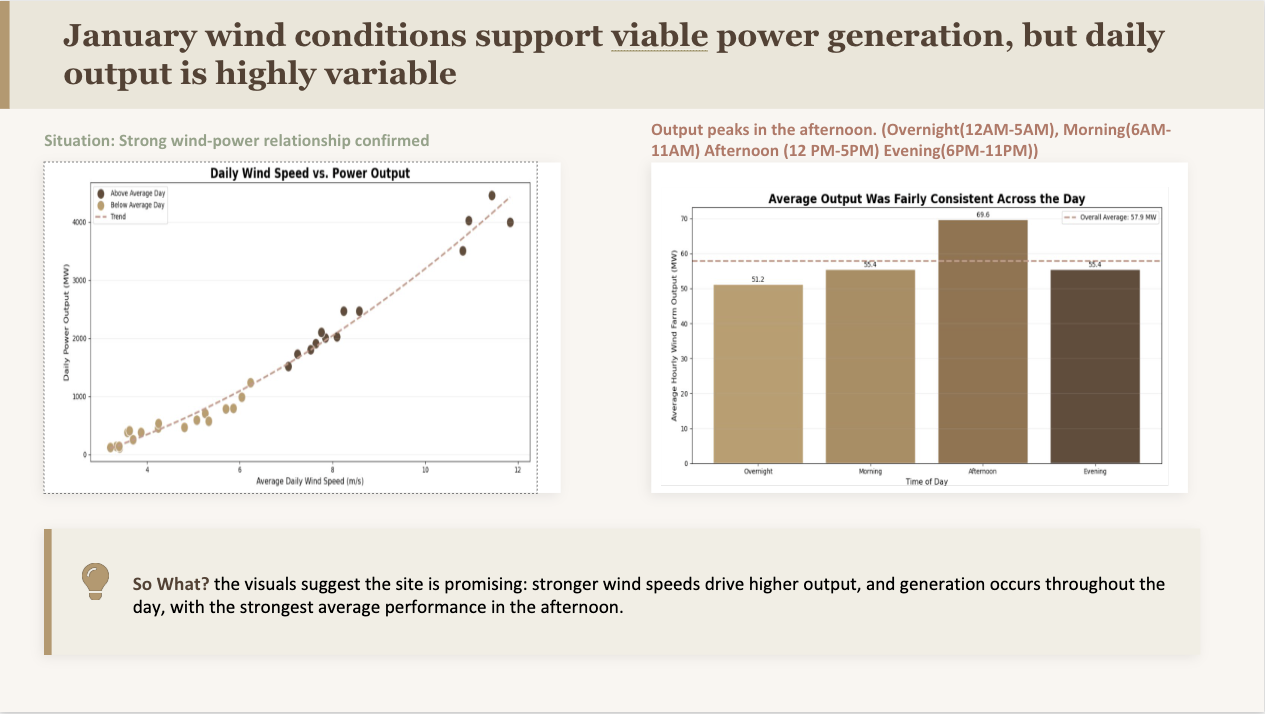

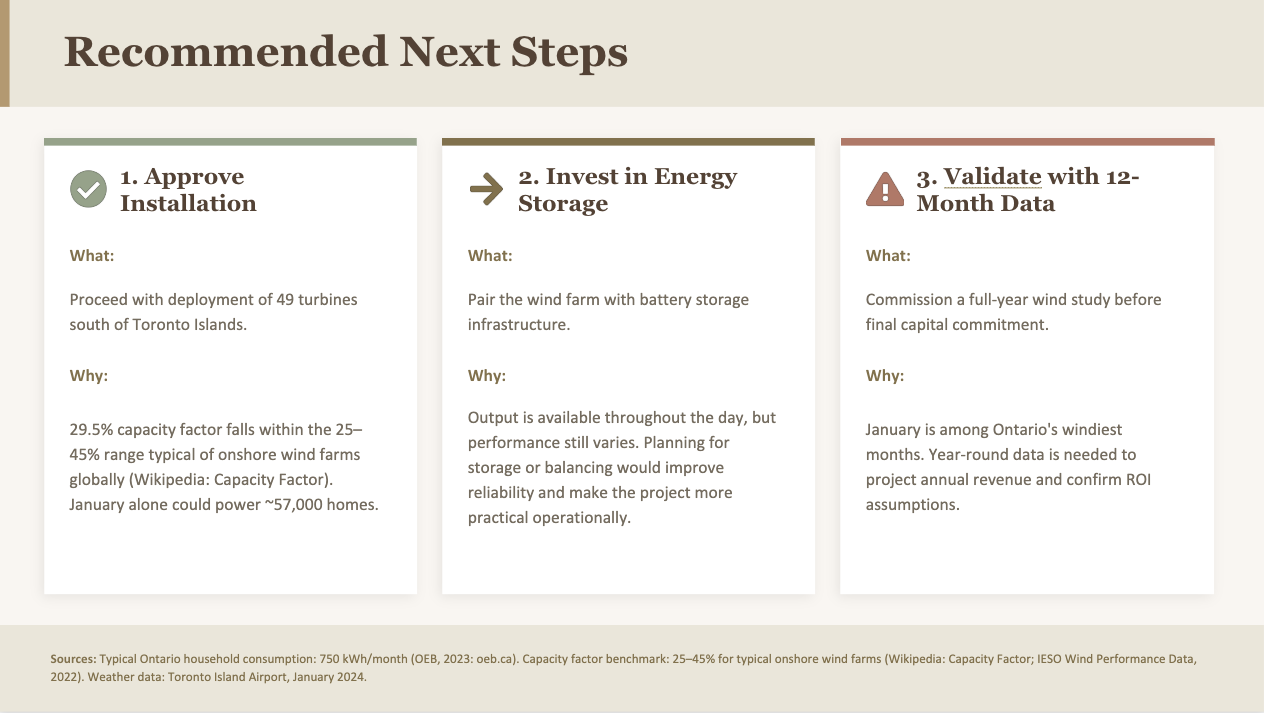

----

# Q3 (Bachir)

Your manager has provided a dataset on product sales, but says she knows little about it. She has told you that it is a bit messy and too difficult for her to work on. Now that you are an expert in Python, she would like you to do the following. Show all your code and a small snippet of relevant output. Both are required for full marks. 

In [19]:
product_sales = pd.read_excel(xl, sheet_name="Product_Sales")

# 3A. Correct variable formats and standardize Product_ID

Make sure all variable formats are correct, and that Product_IDs are all of the same length, and a string. 2 marks

In [20]:
sales = product_sales.copy()
sales["Product_ID"] = sales["Product_ID"].astype(int).astype(str).str.zfill(3)
sales["Price"] = sales["Price"].replace(r"[\$,]", "", regex=True).astype(float)
sales["Import"] = sales["Import"].map({0: "Domestic", 1: "Imported"}).astype("category")
sales[["Product_ID", "Import", "Num_Retailers", "Price"]].head()

,Product_ID,Import,Num_Retailers,Price
0,001,Imported,5,67.18
1,002,Imported,3,54.56
2,003,Domestic,5,58.85
3,004,Domestic,7,56.48
4,005,Imported,7,58.74


# 3B. Tidy the dataset

Tidy the dataset (i.e., make sure all columns are unique variables, all rows are unique observations, and there is a single data point in each cell). See the definition of tidy data from the data exploration cheat sheet. 2 marks

In [21]:
tidy_sales = (
    sales.drop(columns="Obs")
    .melt(
        id_vars=["Product_ID", "Import", "Num_Retailers", "Price"],
        value_vars=["Sales_2016", "Sales_2017"],
        var_name="Year",
        value_name="Sales"
    )
    .assign(Year=lambda d: d["Year"].str.extract(r"(\d{4})").astype(int))
    .sort_values(["Product_ID", "Year"])
    .reset_index(drop=True)
)

tidy_sales.head(8)

,Product_ID,Import,Num_Retailers,Price,Year,Sales
0,001,Imported,5,67.18,2016,1162.91
1,001,Imported,5,67.18,2017,235.19
2,002,Imported,3,54.56,2016,1191.11
3,002,Imported,3,54.56,2017,944.87
4,003,Domestic,5,58.85,2016,1214.96
5,003,Domestic,5,58.85,2017,737.06
6,004,Domestic,7,56.48,2016,1336.07
7,004,Domestic,7,56.48,2017,986.15


# 3C. Visualization of price

Create a visualization of price with appropriate labels. 2 marks

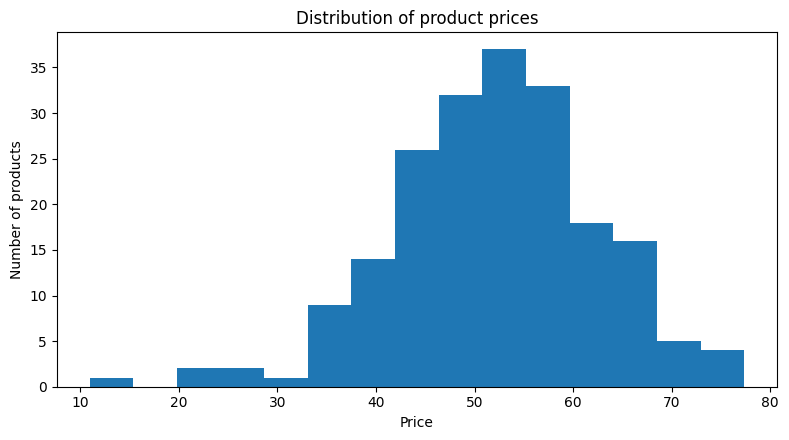

In [22]:
plt.figure(figsize=(8, 4.5))
plt.hist(sales["Price"], bins=15)
plt.title("Distribution of product prices")
plt.xlabel("Price")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

This section creates a histogram to examine the distribution of product prices in the sales dataset. A histogram is appropriate here because price is a continuous numeric variable, and the goal is to understand how values are spread across the product portfolio. The code uses 15 bins to group prices into intervals and show how many products fall into each range.

The chart is clearly labelled with a descriptive title, an x-axis for price, and a y-axis for the number of products, making the visualization easy to interpret. This type of visualization is useful because it quickly reveals whether most products are clustered in a narrow price range, whether prices are broadly dispersed, and whether there are unusually cheap or expensive items. In a business context, this helps a manager understand the product lineup's structure and whether the company appears to compete mainly in a low-, mid-, or premium-market segment. It also provides an early diagnostic check for data quality issues such as extreme outliers or unusual pricing patterns.

> Overall, this section provides a simple yet important summary of the pricing strategy embedded in the dataset and lays the foundation for the more analytical work in the next sections.

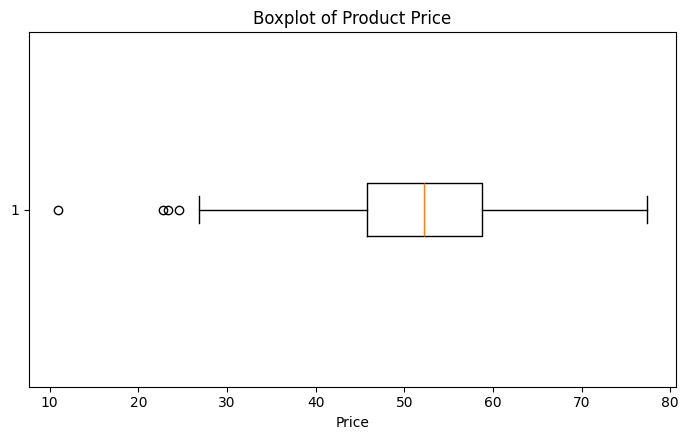

In [23]:
# ---------------------------------------------------------
# 1. Boxplot of price
# Helps show median, spread, and possible outliers
# ---------------------------------------------------------
plt.figure(figsize=(7, 4.5))
plt.boxplot(sales["Price"].dropna(), vert=False)
plt.title("Boxplot of Product Price")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

The boxplot summarizes the distribution of product prices. The median price is around 52, indicating that half of the products are priced above and below this value. 

The interquartile range (approximately 46 to 59) shows that most products are concentrated within this mid-price range. The whiskers extend from about 28 to 78, representing the overall spread of typical prices. There are a few lower-end outliers around 10 and the low 20s, suggesting some unusually inexpensive products compared to the rest. 

> Overall, the distribution is slightly skewed toward higher prices, but most products are clustered in a moderate pricing range rather than at extremes.

# 3D. Correlation between price and number of retailers

Calculate the correlation between price and number of retailers (In python: np.corrcoef()). Produce a scatterplot to visualize it, and explain what the correlation means in practical terms (i.e., to a business owner)  3 marks

In [26]:
corr = np.corrcoef(sales["Price"], sales["Num_Retailers"])[0, 1]
print(round(corr, 4))

-0.0502


This section examines the relationship between product price and the number of retailers that carry each product. The code calculates the Pearson correlation coefficient using np.corrcoef(), then extracts the relevant value from the correlation matrix. 

The result is approximately -0.0502, which is extremely close to zero. In practical terms, this means there is essentially no meaningful linear relationship between a product's price and the number of retailers that sell it. For a business owner, the takeaway is that price alone does not appear to explain retail distribution in this dataset. Products with higher prices are not clearly sold by fewer retailers, and lower-priced products are not clearly sold by more retailers. 

This suggests that other factors, such as brand strength, product category, demand, margins, or retailer strategy, are likely more important in determining how widely a product is carried. The scatterplot complements the correlation by allowing a visual assessment of the pattern. If the points are widely dispersed and show no clear upward or downward trend, that supports the conclusion from the correlation coefficient. 

> Together, the statistic and the visualization provide both numerical and visual evidence that price is not a strong driver of retailer count in this case.

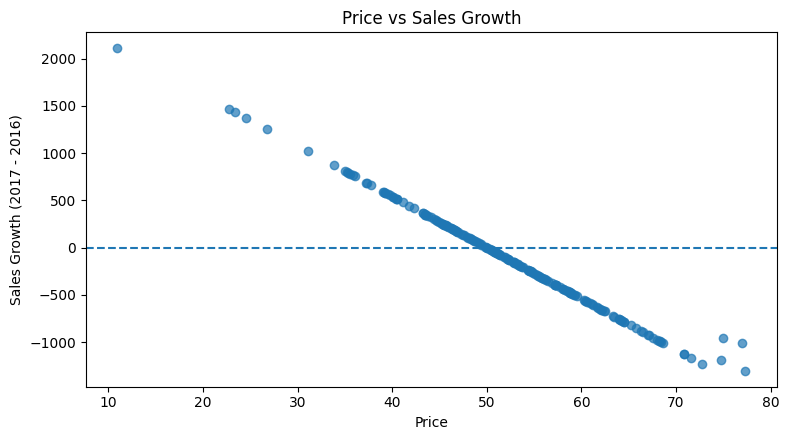

In [46]:
# ---------------------------------------------------------
# 6. Scatterplot: price vs sales growth
# Helps support the story in 3e visually
# ---------------------------------------------------------
plt.figure(figsize=(8, 4.5))
plt.scatter(sales["Price"], sales["Sales_Growth"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Price vs Sales Growth")
plt.xlabel("Price")
plt.ylabel("Sales Growth (2017 - 2016)")
plt.tight_layout()
plt.show()

This scatterplot shows a strong negative relationship between price and sales growth. As prices rise, sales growth consistently declines, indicating that lower-priced products tend to perform better over time. Lower-priced products show strong growth, while higher-priced products are associated with significant sales declines. The clear downward trend suggests that price is a key factor influencing performance in this dataset. 

The dashed horizontal line at zero highlights the transition from positive to negative growth, with most high-priced products falling below it. 

> Overall, the chart suggests that more affordable products drive growth, while premium products struggle to maintain or increase sales.

# 3E. Tell a story with the data

Tell a story with the data - produce an easy to understand visualization and describe the insights you’ve identified to your manager. Make sure the visualization can stand on its own without explanation, and that your story has a specific business purpose or outcome. 3 marks

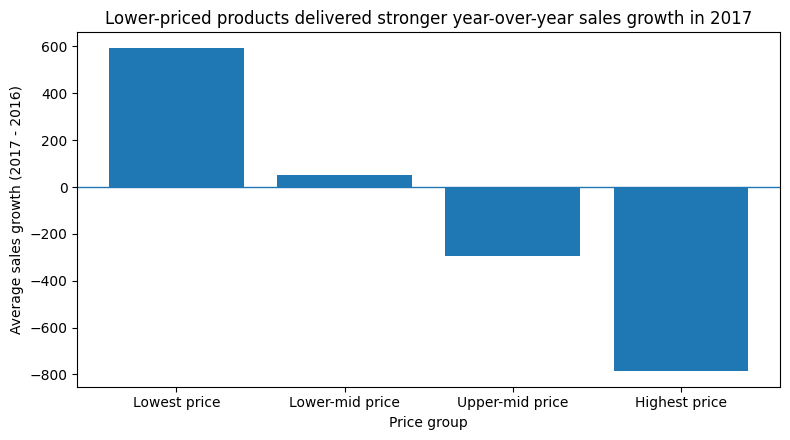

In [28]:
sales["Sales_Growth"] = sales["Sales_2017"] - sales["Sales_2016"]
sales["Price_Group"] = pd.qcut(
    sales["Price"],
    4,
    labels=["Lowest price", "Lower-mid price", "Upper-mid price", "Highest price"]
)

story = (
    sales.groupby("Price_Group", observed=False)["Sales_Growth"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4.5))
plt.bar(story["Price_Group"], story["Sales_Growth"])
plt.axhline(0, linewidth=1)
plt.title("Lower-priced products delivered stronger year-over-year sales growth in 2017")
plt.xlabel("Price group")
plt.ylabel("Average sales growth (2017 - 2016)")
plt.tight_layout()
plt.show()

This section moves beyond description and correlation to develop a business story from the data. The code first creates a new variable called Sales_Growth, calculated as sales in 2017 minus sales in 2016. This measures year-over-year change for each product. Next, products are divided into four price groups using pd.qcut(), which creates roughly equal-sized groups ranging from the lowest price to the highest price. 

The code then calculates the average sales growth within each group and displays the results in a bar chart. This is an effective storytelling visualization because it directly connects pricing position to sales performance and uses a title that communicates the main message immediately. The chart is easy for a manager to understand without a technical explanation. 

The business insight suggested by the title and the grouped averages is that lower-priced products achieved stronger year-over-year sales growth than higher-priced products. If this pattern is reliable, it may indicate stronger customer demand in value-oriented segments, possible resistance to higher prices, or better market traction for more affordable products. 

> From a managerial perspective, this could support decisions about pricing, promotion, assortment planning, or retailer focus. The section is valuable because it translates raw data into an actionable commercial insight.

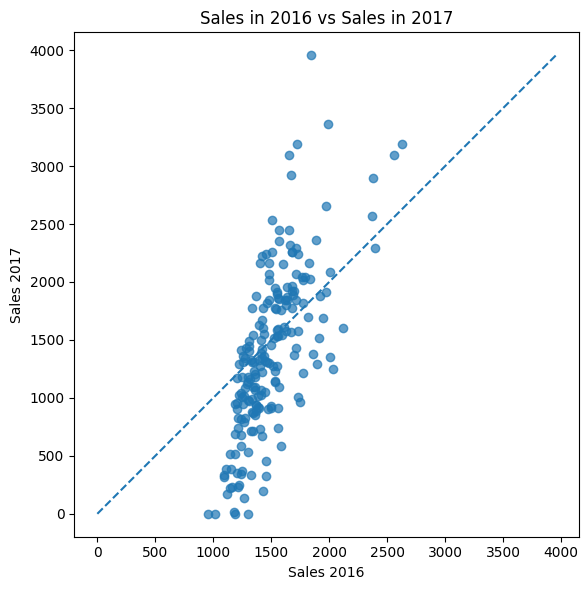

In [29]:
# ---------------------------------------------------------
# 2. Sales 2016 vs Sales 2017 scatterplot
# Helps show whether products improved or declined
# ---------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(sales["Sales_2016"], sales["Sales_2017"], alpha=0.7)
max_val = max(sales["Sales_2016"].max(), sales["Sales_2017"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.title("Sales in 2016 vs Sales in 2017")
plt.xlabel("Sales 2016")
plt.ylabel("Sales 2017")
plt.tight_layout()
plt.show()

This scatterplot shows a strong negative relationship between price and sales growth. As prices rise, sales growth consistently declines, indicating that lower-priced products tend to perform better over time. Lower-priced products show strong growth, while higher-priced products are associated with significant sales declines. The clear downward trend suggests that price is a key factor influencing performance in this dataset.

The dashed horizontal line at zero highlights the transition from positive to negative growth, with most high-priced products falling below it. 

> Overall, the chart suggests that more affordable products drive growth, while premium products struggle to maintain or increase sales.

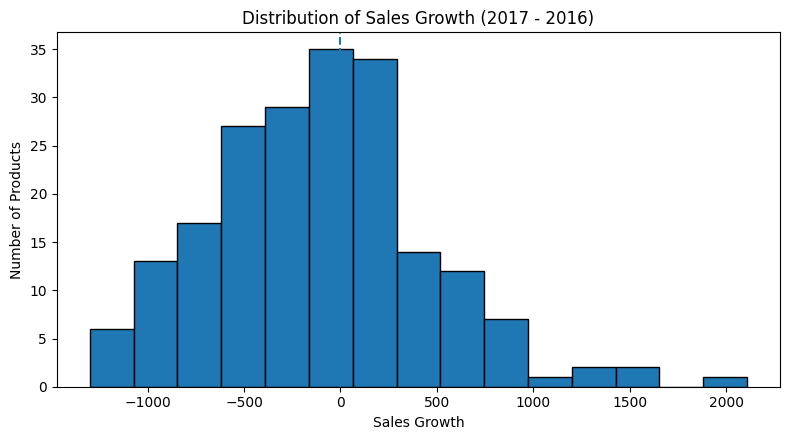

In [30]:
# ---------------------------------------------------------
# 3. Histogram of sales growth
# Helps show how many products increased or decreased
# ---------------------------------------------------------
sales["Sales_Growth"] = sales["Sales_2017"] - sales["Sales_2016"]

plt.figure(figsize=(8, 4.5))
plt.hist(sales["Sales_Growth"].dropna(), bins=15, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribution of Sales Growth (2017 - 2016)")
plt.xlabel("Sales Growth")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

This histogram shows the distribution of sales growth from 2016 to 2017 across all products. The vertical dashed line at zero separates products with declining sales (left) from those with increasing sales (right). Most products are clustered around zero, indicating relatively small year-over-year changes in sales. 

However, there are more observations on the negative side, suggesting that more products experienced declines than growth. The distribution is slightly skewed, with a few products showing very high positive growth, acting as outliers.

> Overall, the chart indicates mixed performance, with modest changes for most products and a few extreme cases.

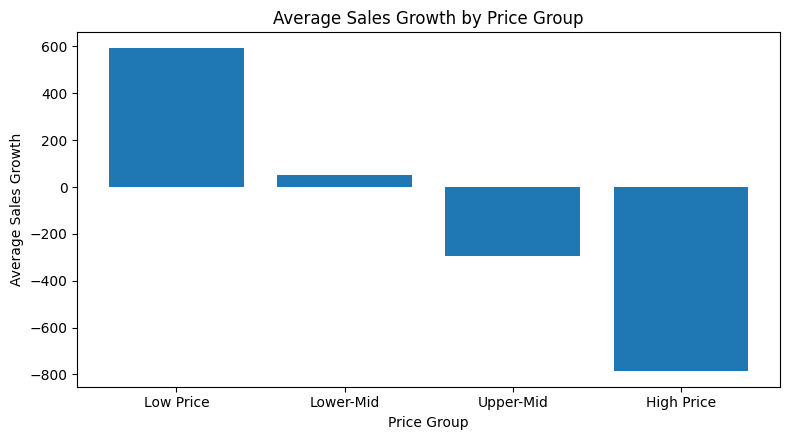

In [31]:
# ---------------------------------------------------------
# 4. Bar chart of average sales growth by price group
# Easier to interpret than raw product-level values
# ---------------------------------------------------------
sales["Price_Group"] = pd.qcut(
    sales["Price"],
    q=4,
    labels=["Low Price", "Lower-Mid", "Upper-Mid", "High Price"]
)

growth_by_group = sales.groupby("Price_Group", observed=False)["Sales_Growth"].mean().reset_index()

plt.figure(figsize=(8, 4.5))
plt.bar(growth_by_group["Price_Group"], growth_by_group["Sales_Growth"])
plt.title("Average Sales Growth by Price Group")
plt.xlabel("Price Group")
plt.ylabel("Average Sales Growth")
plt.tight_layout()
plt.show()

This bar chart shows the average sales growth for products grouped by price level. The results indicate a clear pattern: lower-priced products experienced the highest positive growth, while higher-priced products saw declining sales. The low-price group has strong positive growth, suggesting higher demand or stronger market performance. 

The lower-mid group shows only slight growth, indicating relatively stable performance. In contrast, the upper-mid and high-price groups both exhibit negative growth, with the high-price group declining the most significantly. This suggests that more expensive products may be facing weaker demand, while more affordable products are driving overall growth.

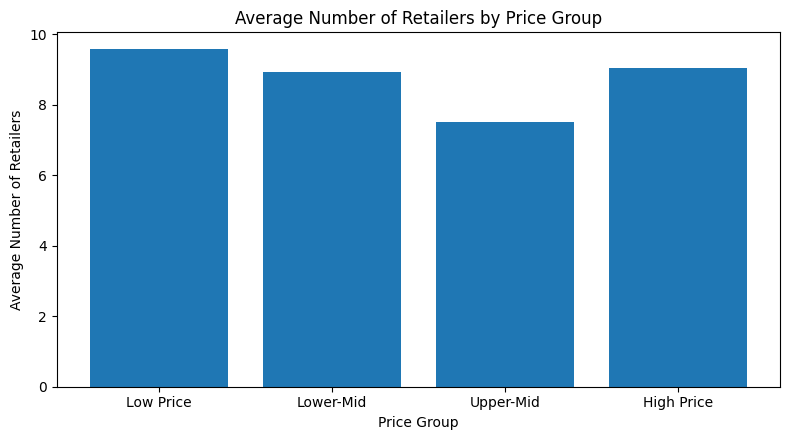

In [32]:
# ---------------------------------------------------------
# 5. Average number of retailers by price group
# Helps connect pricing to distribution strategy
# ---------------------------------------------------------
retailers_by_group = sales.groupby("Price_Group", observed=False)["Num_Retailers"].mean().reset_index()

plt.figure(figsize=(8, 4.5))
plt.bar(retailers_by_group["Price_Group"], retailers_by_group["Num_Retailers"])
plt.title("Average Number of Retailers by Price Group")
plt.xlabel("Price Group")
plt.ylabel("Average Number of Retailers")
plt.tight_layout()
plt.show()

This bar chart shows the average number of retailers carrying products across different price groups. The low-price group has the highest average number of retailers, indicating that cheaper products tend to have wider distribution.

The lower-, mid-, and high-priced groups have similar retailer averages, suggesting that higher-priced products are not necessarily in short supply. The upper-mid group has the lowest average, suggesting weaker demand or more selective distribution strategies. 

> Overall, the differences across groups are relatively small, suggesting that price does not strongly determine how widely a product is distributed, supporting the earlier correlation results.

----------

# Q4 (Lionel & Alan)

Collinearity: collections of variables that tend to move together, such as height and weight, are called collinear.  This creates some challenges for analysis in that individual t-statistics tend to be less informative.  Using the data found on the tab ‘Collinear’:

## Part a)
Filter the data to consider only the first 25 observations then run the following models; repeat the analysis with all 100 observations. You do not need to worry about standard data problems such as heteroscedasticity, etc. You must run 6 regressions in total – i, ii, and iii with 25 observations + i, ii, iii with 100 observations. Include a summary of your models and how you reached your conclusion.

In [33]:
collinearity_data = pd.read_excel(xl, sheet_name='Collinearity')
collinearity_data.head()

,Obs,Y,Experience,Height,Weight
0,1,450,3,52,58
1,2,330,3,33,36
2,3,505,5,37,52
3,4,254,3,44,52
4,5,186,2,14,27


# Create the two required samples

In [34]:
'''
Here two sets of samples are built for Q4:
1) use only the first 25 observations
2) repeat the analysis with all 100 observations
'''
collinearity_25 = collinearity_data.head(25).copy()
collinearity_100 = collinearity_data.copy()

print('First sample count:', len(collinearity_25))
print('All sample count:', len(collinearity_100))

First sample count: 25
All sample count: 100


### Part a) - i)
Run a linear regression to explain y in terms of experience and height.  Does height appear to explain y? 2 marks x2

In [35]:
'''
Model i: Y explained by Experience and Height
'''
model_25_height = ols('Y ~ Experience + Height', data=collinearity_25).fit()
model_100_height = ols('Y ~ Experience + Height', data=collinearity_100).fit()

print("Model used for first 25 observations")
print(model_25_height.summary())  
print("Model used for all 100 observations")
print(model_100_height.summary())

table1 = pd.DataFrame([
    ['First 25', 'Y ~ Experience + Height', 'Height', model_25_height.pvalues['Height']],
    ['All 100', 'Y ~ Experience + Height', 'Height', model_100_height.pvalues['Height']],
], columns=['Sample', 'Model', 'Variable tested', 'p_value'])

table1.round(6)

Model used for first 25 observations
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     79.49
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           8.56e-11
Time:                        18:24:43   Log-Likelihood:                -138.40
No. Observations:                  25   AIC:                             282.8
Df Residuals:                      22   BIC:                             286.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -3

,Sample,Model,Variable tested,p_value
0,First 25,Y ~ Experience + Height,Height,0.004838
1,All 100,Y ~ Experience + Height,Height,0.000000


**Interpretation:**

- For first 25 observations, height has a coefficient of 1.6693 and is statistically significant with p = 0.004838. That indicates height appears to explain y.
- For all 100 observations, height has a coefficient of 1.2762 and is statistically significant with p = 0.000000. That indicates height appears to explain y.

### Part a) - ii)
Run a linear regression to explain y in terms of experience and weight.  Does weight appear to explain y? 2 marks x2

In [36]:
'''
Model ii: Y explained by Experience and Weight
'''
model_25_weight = ols('Y ~ Experience + Weight', data=collinearity_25).fit()
model_100_weight = ols('Y ~ Experience + Weight', data=collinearity_100).fit()

print(model_25_weight.summary())
print(model_100_weight.summary())

table2 = pd.DataFrame([
    ['First 25', 'Y ~ Experience + Weight', 'Weight', model_25_weight.pvalues['Weight']],
    ['All 100', 'Y ~ Experience + Weight', 'Weight', model_100_weight.pvalues['Weight']],
], columns=['Sample', 'Model', 'Variable tested', 'p_value'])

table2.round(6)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     65.01
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           5.83e-10
Time:                        18:24:46   Log-Likelihood:                -140.58
No. Observations:                  25   AIC:                             287.2
Df Residuals:                      22   BIC:                             290.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -69.9322     40.894     -1.710      0.1

,Sample,Model,Variable tested,p_value
0,First 25,Y ~ Experience + Weight,Weight,0.040773
1,All 100,Y ~ Experience + Weight,Weight,0.000000


**Interpretation:**

- For first 25 observations, weight has a coefficient of 1.5973 and is statistically significant with p = 0.040773. That indicates weight appears to explain y.
- For all 100 observations, weight has a coefficient of 1.5527 and is statistically significant with p = 0.000000. That indicates weight appears to explain y.

### Part a) - iii)
Run a linear regression to explain y in terms of experience and height and weight. Do height and weight appear to explain y? 2 marks x2

In [37]:
'''
Model iii: Y explained by Experience, Height, and Weight
'''
model_25_both = ols('Y ~ Experience + Height + Weight', data=collinearity_25).fit()
model_100_both = ols('Y ~ Experience + Height + Weight', data=collinearity_100).fit()

print(model_25_both.summary())
print(model_100_both.summary())

table3 = pd.DataFrame([
    ['First 25', 'Y ~ Experience + Height + Weight', 'Height', model_25_both.pvalues['Height']],
    ['First 25', 'Y ~ Experience + Height + Weight', 'Weight', model_25_both.pvalues['Weight']],
    ['All 100', 'Y ~ Experience + Height + Weight', 'Height', model_100_both.pvalues['Height']],
    ['All 100', 'Y ~ Experience + Height + Weight', 'Weight', model_100_both.pvalues['Weight']],
], columns=['Sample', 'Model', 'Variable tested', 'p_value'])

table3.round(6)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     51.17
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           7.89e-10
Time:                        18:24:50   Log-Likelihood:                -138.27
No. Observations:                  25   AIC:                             284.5
Df Residuals:                      21   BIC:                             289.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -26.5362     43.584     -0.609      0.5

,Sample,Model,Variable tested,p_value
0,First 25,Y ~ Experience + Height + Weight,Height,0.051742
1,First 25,Y ~ Experience + Height + Weight,Weight,0.648735
2,All 100,Y ~ Experience + Height + Weight,Height,0.000351
3,All 100,Y ~ Experience + Height + Weight,Weight,0.944743


**Interpretation:**
 
- For first 25 observations, height has a coefficient of 2.0557 and is not statistically significant with p = 0.051742, and weight has a coefficient of -0.5822 and is not statistically significant with p = 0.648735. That indicates both height and weight now does not appears to explain y.
- For all 100 observations, height has a coefficient of 1.2968 and is statistically significant with p = 0.000351, and weight has a coefficient of -0.0351 and is not statistically significant with p = 0.944743. That indicates here only height does appears to explain y.

## Part b) - Explanation to Manager

Question: b.	Consider the results you have found from the work in a. Write a paragraph or two to explain to your manager the patterns you observed with respect to the significance of the t-statistics, why these results occurred, and the strategies for using explanatory variables that exhibit collinearity. 3 marks

Answer: 

When we tested height and weight separately in our models, both variables appeared to be 
statistically significant predictors of Y — each one, on its own, seemed to matter. 
Height was significant in both the 25 and 100 observation models (p = 0.005 and p ≈ 0.000), 
and weight was also significant in both (p = 0.041 and p ≈ 0.000). Based on these results 
alone, one might conclude that both height and weight are important drivers of Y.

However, when we included both height and weight in the same model together, something 
changed significantly. Weight became completely insignificant — its p-value jumped to 0.649 
with 25 observations and 0.945 with 100 observations. With the smaller sample of 25, even 
height lost its significance, coming in just above the 0.05 threshold at p = 0.052. This is 
a classic example of collinearity — height and weight tend to move together, meaning taller 
people generally weigh more. Because these two variables are so closely related, the model 
cannot separate their individual contributions to Y. It essentially gets confused about which 
one is doing the explaining, causing the reliability of both to drop.

The practical takeaway is this: when two variables are highly correlated, including both in 
the same model does not give us more information — it actually makes our results less 
trustworthy. The strategies to deal with this are: pick one of the two correlated variables 
and drop the other, since they carry similar information; or combine them into a single 
measure such as BMI, which captures the underlying concept without the redundancy. 
Importantly, experience remained strongly significant across all six models, confirming it 
is the most reliable driver of Y regardless of what other variables are included.

## Q4 Supporting Visual:

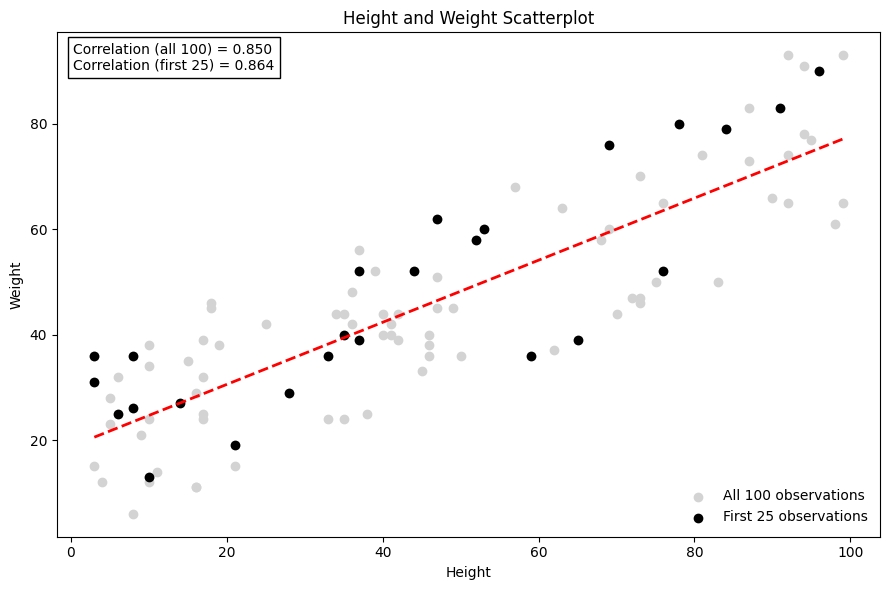

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))
 
ax.scatter(

    collinearity_100['Height'],

    collinearity_100['Weight'],

    c='lightgray',

    label='All 100 observations',

)

ax.scatter(

    collinearity_25['Height'],

    collinearity_25['Weight'],

    c='black',

    label='First 25 observations',

)
 
slope, intercept = np.polyfit(collinearity_100['Height'], collinearity_100['Weight'], 1)

x_values = np.linspace(collinearity_100['Height'].min(), collinearity_100['Height'].max(), 100)

ax.plot(x_values, slope * x_values + intercept, color='red', linestyle='dashed', linewidth=2)
 
corr_all = collinearity_100[['Height', 'Weight']].corr().iloc[0, 1]

corr_25 = collinearity_25[['Height', 'Weight']].corr().iloc[0, 1]
 
ax.set_title('Height and Weight Scatterplot')

ax.set_xlabel('Height')

ax.set_ylabel('Weight')

ax.legend(frameon=False)

ax.text(

    0.02,

    0.98,

    (

        f'Correlation (all 100) = {corr_all:.3f}\n'

        f'Correlation (first 25) = {corr_25:.3f}'

    ),

    transform=ax.transAxes,

    va='top',

    ha='left',

    bbox={'facecolor': 'white', 'edgecolor': 'black'},

)
 
fig.tight_layout()

plt.show()

 

---